# 08 — Noisy Steane-Code Decoding

## Read before you begin

- Recap (no new material): the "decoding by error cosets" discussion in Arthur Pesah's *Stabilizer Formalism III* (https://arthurpesah.me/blog/2023-03-28-stabilizer-formalism-3/), covered in notebook 07 — this notebook puts it under actual noise for the first time.
- Stim's official Gate Reference (https://github.com/quantumlib/Stim/wiki, and `doc/gates.md` in the [quantumlib/Stim](https://github.com/quantumlib/Stim) repository), specifically the noise channels `X_ERROR`, `Z_ERROR`, and the multi-Pauli-product measurement instruction `MPP`. Every instruction used below was checked directly against the installed `stim` package with `stim.gate_data(...)` before use, in addition to the public docs.
- Concepts to extract: how Stim represents independent single-qubit noise; how `MPP` measures a Pauli-string stabilizer (like a 4-qubit $X$-check) in a single instruction, without needing to hand-build an ancilla circuit the way notebook 01 did.

## Learning objectives

1. inject independent, per-qubit Pauli noise onto the Steane code's 7 data qubits;
2. build a lookup-table decoder that reuses notebook 04's classical Hamming decoder unmodified for both the $X$-error and $Z$-error channels;
3. measure physical vs. logical failure probability by Monte Carlo simulation, and check it against an exact closed-form combinatorial formula;
4. explain why decoding the $X$- and $Z$-channels *independently* is correct here specifically because of the Steane code's CSS structure (notebook 07) — this is this code's version of exploiting degeneracy;
5. see the same syndromes reproduced inside an actual Stim circuit using real noise instructions and `MPP`;
6. state plainly what this decoder does *not* handle, and what a real decoder (notebook 10) adds.

**Expected outputs:** one Monte Carlo logical-failure-rate curve across a range of physical error rates, matching a derived closed-form formula almost exactly; and one verified Stim circuit reproducing the same syndrome behavior as the classical simulation.

**Assumes:** notebook 04 (Hamming decoding), notebook 05 (Steane stabilizers), and notebook 07 (CSS block structure, syndromes as matrix-vector products).

## 1. Reusing the classical Hamming decoder, unchanged

The Steane code's $X$-type stabilizers only ever detect $Z$ errors, and its $Z$-type stabilizers only ever detect $X$ errors (notebook 05, Section 7) — and because both are built from the *same* $H$, notebook 04's `decode` function, unmodified, is already a correct single-error decoder for *either* channel.

In [1]:
def bits_of(j, width):
    return tuple((j >> shift) & 1 for shift in reversed(range(width)))


H_columns = [bits_of(j, width=3) for j in range(1, 8)]
H = tuple(tuple(col[row] for col in H_columns) for row in range(3))


def matvec_gf2(matrix, vec):
    return tuple(sum(a * b for a, b in zip(row, vec)) % 2 for row in matrix)


def bits_to_int(bits):
    value = 0
    for b in bits:
        value = (value << 1) | b
    return value


def xor_vec(u, v):
    return tuple(a ^ b for a, b in zip(u, v))


def decode_error_vector(error_vector):
    """Given a length-7 GF(2) error vector, return the single-bit correction guess."""
    syndrome = matvec_gf2(H, error_vector)
    guessed_position = bits_to_int(syndrome)  # 0 means "no error", else 1-indexed qubit
    correction = tuple(1 if (i + 1) == guessed_position else 0 for i in range(7))
    return correction


print("H =", H)
print("decode_error_vector for a clean vector:", decode_error_vector((0,) * 7))
print("decode_error_vector for a single flip at qubit 2:", decode_error_vector((0, 0, 1, 0, 0, 0, 0)))

H = ((0, 0, 0, 1, 1, 1, 1), (0, 1, 1, 0, 0, 1, 1), (1, 0, 1, 0, 1, 0, 1))
decode_error_vector for a clean vector: (0, 0, 0, 0, 0, 0, 0)
decode_error_vector for a single flip at qubit 2: (0, 0, 1, 0, 0, 0, 0)


## 2. When does this decoder fail?

The decoder's correction always has weight 0 or 1 (it's either "no error" or a single guessed qubit). Its guess always has the *same syndrome* as the true error (that's how the guess was chosen), so the **residual** — true error XOR correction — always has zero syndrome, meaning **the residual is always a codeword of the classical Hamming code** (notebook 04, Section 4). A nonzero codeword has weight at least 3 (notebook 04's distance-3 result), so:

- if the true error has weight 0 or 1, the correction exactly cancels it: residual = 0, **success**;
- if the true error has weight $\ge 2$, the residual is generally a nonzero codeword — an **undetected logical error** on that channel, since (via the CSS construction) a nonzero classical Hamming codeword used as an $X$ residual is exactly a nontrivial Steane logical operator.

This gives a clean, checkable prediction: **failure on one channel happens exactly when 2 or more of that channel's 7 qubits are hit.**

### Prediction 1

**Before running the next cell:** for independent per-qubit error probability $p$ on 7 qubits, write down (on paper) the exact probability that *0 or 1* qubits are hit — this is $P(\text{success})$ for one channel. What closed-form expression do you get for $P(\text{failure}) = 1 - P(\text{success})$?

In [2]:
from math import comb


def exact_channel_failure_probability(p, n=7):
    # P(success) = P(0 or 1 of the n qubits hit), i.e. the k=0 and k=1 terms of
    # the binomial PMF comb(n, k) * p**k * (1-p)**(n-k); failure is the complement.
    p_success = sum(comb(n, k) * p ** k * (1 - p) ** (n - k) for k in (0, 1))
    return 1 - p_success


for p in [0.01, 0.05, 0.1, 0.3]:
    print(f"p={p:<5} exact channel failure probability = {exact_channel_failure_probability(p):.5f}")

p=0.01  exact channel failure probability = 0.00203
p=0.05  exact channel failure probability = 0.04438
p=0.1   exact channel failure probability = 0.14969
p=0.3   exact channel failure probability = 0.67058


## 3. Monte Carlo simulation, and checking it against the exact formula

In [3]:
import random


def sample_error_vector(p, n=7):
    return tuple(1 if random.random() < p else 0 for _ in range(n))


def channel_failure_rate(p, trials, rng_seed=0):
    random.seed(rng_seed)
    failures = 0
    for _ in range(trials):
        error = sample_error_vector(p)
        correction = decode_error_vector(error)
        residual = xor_vec(error, correction)
        if any(residual):
            failures += 1
    return failures / trials


trials = 200_000
for p in [0.01, 0.05, 0.1, 0.3]:
    simulated = channel_failure_rate(p, trials)
    exact = exact_channel_failure_probability(p)
    print(f"p={p:<5} simulated={simulated:.5f}  exact={exact:.5f}  difference={abs(simulated - exact):.5f}")

p=0.01  simulated=0.00202  exact=0.00203  difference=0.00001


p=0.05  simulated=0.04464  exact=0.04438  difference=0.00025


p=0.1   simulated=0.14994  exact=0.14969  difference=0.00024


p=0.3   simulated=0.67107  exact=0.67058  difference=0.00049


### Prediction 2

**Before running the next cell:** at what physical error rate $p$ do you expect the logical (channel) failure probability to cross the line $y=p$ — i.e., where does encoding stop helping? Is it higher or lower than notebook 02's repetition-code break-even point (which was $p=0.5$)?

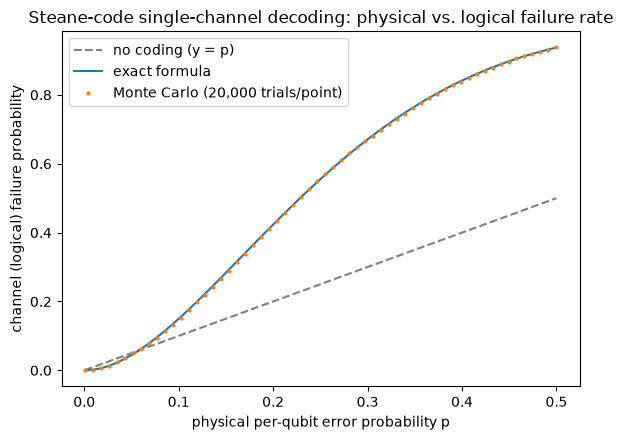

Break-even point (exact formula crosses y=p): p = 0.058


In [4]:
import matplotlib.pyplot as plt
import numpy as np

p_values = np.linspace(0.001, 0.5, 60)
exact_curve = [exact_channel_failure_probability(p) for p in p_values]
simulated_curve = [channel_failure_rate(p, trials=20_000, rng_seed=1) for p in p_values]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(p_values, p_values, "--", color="gray", label="no coding (y = p)")
ax.plot(p_values, exact_curve, "-", label="exact formula")
ax.plot(p_values, simulated_curve, ".", markersize=4, label="Monte Carlo (20,000 trials/point)")
ax.set_xlabel("physical per-qubit error probability p")
ax.set_ylabel("channel (logical) failure probability")
ax.set_title("Steane-code single-channel decoding: physical vs. logical failure rate")
ax.legend()
fig.tight_layout()
plt.show()

# Find the sign change of (failure(p) - p): below it coding helps, above it coding hurts.
# (Minimizing |failure(p) - p| directly is wrong here -- both go to 0 as p -> 0, so that
# metric is smallest at the smallest sampled p, never at the actual crossing.)
fine_p = np.linspace(0.001, 0.5, 5000)
signed_gap = np.array([exact_channel_failure_probability(p) - p for p in fine_p])
sign_change_index = np.argmax(signed_gap > 0)
crossing = fine_p[sign_change_index]
print(f"Break-even point (exact formula crosses y=p): p = {crossing:.3f}")

The Monte Carlo points track the exact formula closely, and the break-even point is noticeably *lower* than the repetition code's $p=0.5$ — the Steane code needs 2 simultaneous errors among 7 qubits to fail on a channel, which becomes likely at a smaller $p$ than the repetition code's "2 out of 3" failure condition. Protecting more qubits per block does not automatically raise the tolerable error rate; that depends on the code's distance, not just its size (both codes have distance 3, but the *combinatorics* of "how many ways can 2 errors land" differ: $\binom{3}{2}=3$ vs. $\binom{7}{2}=21$).

## 4. Why decoding $X$ and $Z$ independently is valid: degeneracy in a CSS code

Section 1 decoded the $X$-error channel and the $Z$-error channel completely separately, with no interaction between them. Is that actually safe for a general error, including one that hits *both* channels on the same qubit (a $Y$ error, which is simultaneously an $X$ and a $Z$)?

Because the Steane code's $X$-type and $Z$-type stabilizers commute with *every* Pauli on *any* qubit combination they don't jointly touch in a conflicting way (notebook 07's CSS block structure: the quantum parity-check matrix is block-diagonal, $M = \mathrm{diag}(H,H)$, with **zero** cross-terms between the $X$-part and $Z$-part), the $X$-type syndrome depends *only* on the error's $X$-part, and the $Z$-type syndrome depends *only* on the error's $Z$-part. A $Y$ error is just "$X$ and $Z$ on the same qubit at once" — each channel's decoder sees exactly its own half of that error and corrects it exactly as if the other half didn't exist. This is a direct consequence of the CSS structure, not a coincidence, and it's why a CSS code lets you reuse *one* classical decoder twice instead of needing a genuinely joint quantum decoder — the code's structure has already "resolved" the degeneracy between how $X$- and $Z$-type information mix.

In [5]:
def sample_y_correlated_errors(p, n=7):
    """Independent X and Z error vectors, as if each qubit's error were drawn from {I, X, Y, Z}."""
    x_error = sample_error_vector(p, n)
    z_error = sample_error_vector(p, n)
    return x_error, z_error


random.seed(2)
x_err, z_err = sample_y_correlated_errors(p=0.2)
x_correction = decode_error_vector(x_err)
z_correction = decode_error_vector(z_err)
x_residual = xor_vec(x_err, x_correction)
z_residual = xor_vec(z_err, z_correction)

print("X error:     ", x_err)
print("Z error:     ", z_err)
print("X residual:  ", x_residual, " (nonzero = X-channel failure)")
print("Z residual:  ", z_residual, " (nonzero = Z-channel failure)")
print("\nEach channel was decoded using only its own error vector -- neither decoder ever looked at the other.")

X error:      (0, 0, 1, 1, 0, 0, 0)
Z error:      (0, 0, 0, 0, 1, 0, 0)
X residual:   (0, 0, 1, 1, 0, 0, 1)  (nonzero = X-channel failure)
Z residual:   (0, 0, 0, 0, 0, 0, 0)  (nonzero = Z-channel failure)

Each channel was decoded using only its own error vector -- neither decoder ever looked at the other.


## 5. The same syndromes, inside an actual Stim circuit

Stim's `X_ERROR(p)` and `Z_ERROR(p)` inject exactly this kind of independent per-qubit noise, and `MPP` measures a multi-qubit Pauli product — such as a 4-qubit stabilizer — in a single instruction, with no ancilla qubits or explicit `CX` gates needed (contrast with notebook 01's by-hand ancilla circuit).

In [6]:
import stim

steane_x_checks = ["*".join(f"X{q}" for q in range(7) if row[q]) for row in H]
steane_z_checks = ["*".join(f"Z{q}" for q in range(7) if row[q]) for row in H]
print("X-type stabilizer Pauli strings for MPP:", steane_x_checks)
print("Z-type stabilizer Pauli strings for MPP:", steane_z_checks)

circuit = stim.Circuit()
circuit.append("X_ERROR", range(7), 0.15)
circuit.append("Z_ERROR", range(7), 0.15)

# Build one MPP instruction covering all 3 Z-type checks (they detect X errors).
# Within a single check, target_combiner() joins qubits into one Pauli product;
# a target with NO preceding combiner starts a new, separate check.
mpp_targets = []
for check in steane_z_checks:
    qubits = [int(term[1:]) for term in check.split("*")]  # "Z3*Z4*Z5*Z6" -> [3, 4, 5, 6]
    for i, q in enumerate(qubits):
        if i:
            mpp_targets.append(stim.target_combiner())  # join to the previous qubit in THIS check
        mpp_targets.append(stim.target_x(q))
circuit.append("MPP", mpp_targets)

print("\nCircuit:")
print(circuit)
print("\n5 sampled shots (each row: 3 Z-type-check outcomes, detecting X errors):")
print(circuit.compile_sampler().sample(shots=5))

X-type stabilizer Pauli strings for MPP: ['X3*X4*X5*X6', 'X1*X2*X5*X6', 'X0*X2*X4*X6']
Z-type stabilizer Pauli strings for MPP: ['Z3*Z4*Z5*Z6', 'Z1*Z2*Z5*Z6', 'Z0*Z2*Z4*Z6']

Circuit:
X_ERROR(0.15) 0 1 2 3 4 5 6
Z_ERROR(0.15) 0 1 2 3 4 5 6
MPP X3*X4*X5*X6 X1*X2*X5*X6 X0*X2*X4*X6

5 sampled shots (each row: 3 Z-type-check outcomes, detecting X errors):
[[False False False]
 [ True False  True]
 [ True  True  True]
 [False  True False]
 [ True False  True]]


### Prediction 3

**Before moving on:** if you ran this exact circuit with `X_ERROR` set to probability 0, would every sampled row be all `False`? What does a single `True` in one of these rows tell you, on its own, about *which* qubit is likely to have flipped (compare to Section 1's syndrome-to-position lookup)?

(Answer, briefly: yes, all-`False` with no noise — the checks are only measuring parity, and a clean codeword satisfies every check. And no single measured bit alone names a qubit; only the *combination* of all three, read as a binary number via `bits_to_int`, does — exactly as in notebook 04.)

## 6. Clear limits of this toy decoder

This decoder is deliberately simple, and that has real consequences:

- **It only corrects one error per channel.** Any 2-or-more-qubit error on the same channel is either mis-corrected into a logical failure or, worse, silently accepted as "fixed" when it happens to be a genuine nontrivial logical operator (Section 2) — there is no way to tell these apart from the syndrome alone, ever, for *any* decoder; this is a property of the code, not a decoder weakness.
- **It assumes perfect syndrome measurement.** Real hardware also has measurement errors; a realistic decoder (and the surface-code decoder in notebook 10) has to account for faulty syndrome bits too, not just faulty data qubits.
- **It decodes $X$ and $Z$ independently**, which Section 4 showed is *valid* for a CSS code — but it is not a general-purpose quantum decoding strategy; a non-CSS stabilizer code can mix $X$/$Z$ information in ways that require a joint decoder.
- **It is not a maximum-likelihood decoder.** For the single-error case here the "obvious" guess and the maximum-likelihood guess coincide, but a decoder for a bigger code (like the surface code) generally has to weigh many candidate corrections against each other — the job notebook 10's matching decoder does, and this notebook's lookup table does not.

## Exercises

**1.** Write `combined_failure_rate(p, trials)` that samples *both* channels (reusing `sample_y_correlated_errors`) and reports the probability that *at least one* channel fails (a "block failure," as opposed to Section 3's single-channel failure rate). Is it larger or smaller than `exact_channel_failure_probability(p)`? Can you write a closed-form expression for it, given the two channels are independent?

**2.** Section 5 built the `MPP` targets for only the $Z$-type checks (which detect $X$ errors). Write `build_mpp_targets(check_strings)` that generalizes that construction to take *any* list of Pauli-string checks (like `steane_x_checks`) and returns valid `MPP` targets, then use it to add the $X$-type checks (detecting $Z$ errors) to the circuit from Section 5, so a single circuit reports all 6 syndrome bits at once.

In [7]:
def combined_failure_rate(p, trials):
    pass  # TODO: implement, then remove this stub body


def build_mpp_targets(check_strings):
    pass  # TODO: implement, then remove this stub body


# TODO: once implemented, try e.g.:
# print(combined_failure_rate(0.1, 50_000))
# full_targets = build_mpp_targets(steane_z_checks) + build_mpp_targets(steane_x_checks)
